Import des données

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv(
 'https://www.data.gouv.fr/fr/datasets/r/182268fc-2103-4bcb-a850-6cf90b02a9eb' 
)

/tmp/ipykernel_6182/3306194276.py:3: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


1 Exploration générale

Question 1

In [ ]:
# Ajouter des zéros devant l'ancien code commune
df["code_commune"] = df["code_commune"].astype(str).str.zfill(3)

# Coller le code département et l'ancien code commune
df["code_commune"] = df["code_departement"] + df["code_commune"]

# Nouvelle colonne prénom NOM
df["candidat"] =  df["prenom"] + " " + df["nom"]
print(df)

       code_departement              libelle_departement    code_commune  \
0                    01                              Ain           01001   
1                    01                              Ain           01002   
2                    01                              Ain           01004   
3                    01                              Ain           01005   
4                    01                              Ain           01006   
...                 ...                              ...             ...   
528670      fr_etranger  Français établis hors de France  fr_etranger229   
528671      fr_etranger  Français établis hors de France  fr_etranger231   
528672      fr_etranger  Français établis hors de France  fr_etranger233   
528673      fr_etranger  Français établis hors de France  fr_etranger234   
528674      fr_etranger  Français établis hors de France  fr_etranger235   

                libelle_commune    prenom      nom  voix          candidat  
0       L'

Question 2

In [3]:
# Liste des candidats sans votes nuls
liste_candidat = df["candidat"].dropna().unique()

# Nombre candidats
candidat = len(liste_candidat)

# Affichage du nombre de candidats
print(f"En 2022, il y avait {candidat} candidats à l'élection présidentielle.")

En 2022, il y avait 12 candidats à l'élection présidentielle.


Question 3

In [4]:
score_national = (df.groupby("candidat").agg({'voix': sum}).sort_values('voix', ascending = False))

score_national["Score (% votes exprimés)"] = score_national["voix"] / score_national["voix"].sum() * 100
score_national.rename(columns={'voix': 'Nombre votes (total)'}, inplace=True)   

print(score_national)

                       Nombre votes (total)  Score (% votes exprimés)
candidat                                                             
Emmanuel MACRON                     9783058                 27.845822
Marine LE PEN                       8133828                 23.151568
Jean-Luc MÉLENCHON                  7712520                 21.952386
Éric ZEMMOUR                        2485226                  7.073776
Valérie PÉCRESSE                    1679001                  4.778993
Yannick JADOT                       1627853                  4.633409
Jean LASSALLE                       1101387                  3.134912
Fabien ROUSSEL                       802422                  2.283959
Nicolas DUPONT-AIGNAN                725176                  2.064091
Anne HIDALGO                         616478                  1.754701
Philippe POUTOU                      268904                  0.765390
Nathalie ARTHAUD                     197094                  0.560995


/tmp/ipykernel_6182/3016939936.py:1: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  score_national = (df.groupby("candidat").agg({'voix': sum}).sort_values('voix', ascending = False))


Question 4

In [5]:
# Calcul du nombre de voix des candidats pour chaque département
score_departements = (
    df.groupby(["candidat", "code_departement"])
    .agg({'voix': 'sum'})
    .reset_index()
    .sort_values(
        by=['code_departement', 'voix'], # trie par département et nombre de voix
        ascending=[True, False]
    )
    )

# Calcul du score
score_departements["Score (% votes exprimés)"] = round(
    (
    (score_departements["voix"] /
     score_departements.groupby("code_departement")["voix"]
     .transform("sum") #  somme pour chacun des candidats de chacun des départements
     ) * 100
    ), 2
)

score_departements.rename(columns={'voix': 'votes'}, inplace=True)

Test pour le département de l'Aude (11)

In [6]:
score_departement_11 = score_departements[score_departements["code_departement"] == '11']
print(score_departement_11)

                   candidat code_departement  votes  Score (% votes exprimés)
550           Marine LE PEN               11  64027                     30.14
118         Emmanuel MACRON               11  43104                     20.29
442      Jean-Luc MÉLENCHON               11  42039                     19.79
1198           Éric ZEMMOUR               11  18434                      8.68
334           Jean LASSALLE               11  12382                      5.83
982        Valérie PÉCRESSE               11   7350                      3.46
1090          Yannick JADOT               11   6322                      2.98
10             Anne HIDALGO               11   6166                      2.90
226          Fabien ROUSSEL               11   5622                      2.65
766   Nicolas DUPONT-AIGNAN               11   4206                      1.98
874         Philippe POUTOU               11   1748                      0.82
658        Nathalie ARTHAUD               11   1026             

Question 5

In [7]:
# Renommer les variables
score_national.rename(columns={
    "Score (% votes exprimés)": "score_national"
}, inplace=True)
score_national.rename(columns={
    "Nombre votes (total)": "vote_national"
}, inplace=True)

score_departements.rename(columns={
    "votes": "vote_departement"
}, inplace=True)
score_departements.rename(columns={
    "Score (% votes exprimés)": "score_departement"
}, inplace=True)

# Jointure
score_joint = score_departements.merge(
    score_national,
    on="candidat",
    how="left"
)

Test pour le département de l'Aude (11)

In [8]:
score_joint_11 = score_joint[
    score_joint["code_departement"] == "11"
]

print(score_joint_11)

                  candidat code_departement  vote_departement  \
120          Marine LE PEN               11             64027   
121        Emmanuel MACRON               11             43104   
122     Jean-Luc MÉLENCHON               11             42039   
123           Éric ZEMMOUR               11             18434   
124          Jean LASSALLE               11             12382   
125       Valérie PÉCRESSE               11              7350   
126          Yannick JADOT               11              6322   
127           Anne HIDALGO               11              6166   
128         Fabien ROUSSEL               11              5622   
129  Nicolas DUPONT-AIGNAN               11              4206   
130        Philippe POUTOU               11              1748   
131       Nathalie ARTHAUD               11              1026   

     score_departement  vote_national  score_national  
120              30.14        8133828       23.151568  
121              20.29        9783058     

Question 6

In [9]:
score_joint["surrepresentation (%)"] = round(
    (
        score_joint["score_departement"] /
        score_joint["score_national"] - 1
    ) * 100,
    2
)
print(score_joint)

                   candidat code_departement  vote_departement  \
0           Emmanuel MACRON               01             92206   
1             Marine LE PEN               01             86755   
2        Jean-Luc MÉLENCHON               01             57832   
3              Éric ZEMMOUR               01             27530   
4          Valérie PÉCRESSE               01             17572   
...                     ...              ...               ...   
1291  Nicolas DUPONT-AIGNAN      fr_etranger              7074   
1292          Jean LASSALLE      fr_etranger              5964   
1293         Fabien ROUSSEL      fr_etranger              3266   
1294        Philippe POUTOU      fr_etranger              3145   
1295       Nathalie ARTHAUD      fr_etranger              1300   

      score_departement  vote_national  score_national  surrepresentation (%)  
0                 27.69        9783058       27.845822                  -0.56  
1                 26.05        8133828       23

Question 7

In [10]:
def top_surrepresentation(top_n, nom_candidat):
    """
    Affiche les principales surreprésentations 
    (en valeur absolue) par département

    Parameters
    ----------
    n: int
    Représente les n premières 
    surreprésentations

    candidat : str
    Nom du candidat dont on veut 
    les surreprésentations
    """
    # Recherche index du candidat
    index_cand = score_joint['candidat'].str.contains(nom_candidat, case=False, na=False)

    # Copie avec seulement le candidat pour ne pas modifier le dataframe 
    copie_score = score_joint[index_cand].copy()
    
    # Index du top n
    top_abs = (
        copie_score['surrepresentation (%)'].abs().nlargest(5)
        .index
        )
    
    # Sélection de ces n lignes et tri (plus haut vers plus bat)
    top_deviations = (
        copie_score
        .loc[top_abs]
        .sort_values(by='surrepresentation (%)', ascending=False)
        )
    
    # Graphique
    plt.barh("code_departement", "surrepresentation (%)", data=top_deviations)
    plt.axvline(x=0)
    plt.xlabel('Surreprésentation')
    plt.ylabel('Département')
    plt.title(f'Top {top_n} des surreprésentations de {nom_candidat}')
    plt.show()

Test pour le top 5 de ZEMMOUR

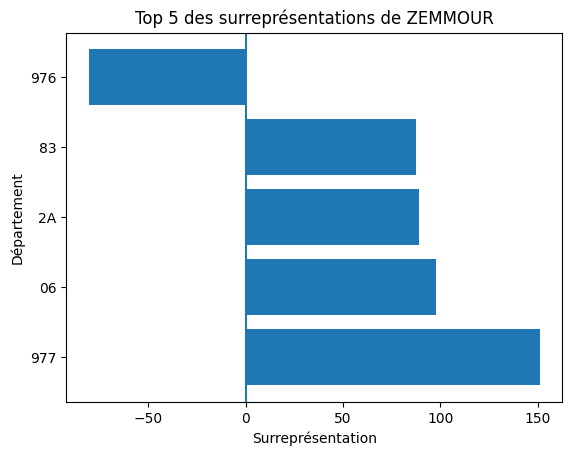

In [11]:
top_surrepresentation(5, "ZEMMOUR")

Question 8

In [12]:
from cartiflette import carti_download

departement_borders = carti_download(
 values = ["France"],
 crs = 4326,
 borders = "DEPARTEMENT",
 vectorfile_format="geojson",
 simplification=50,
 filter_by="FRANCE_ENTIERE_DROM_RAPPROCHES",
 source="EXPRESS-COG-CARTO-TERRITOIRE",
 year=2022)

ModuleNotFoundError: No module named 'cartiflette'

In [ ]:
# Nom des colonnes
print("Colonnes IGN :", departement_borders.columns)
# Jointure à faire sue INSEE_DEP

def score_candidat(candidat):
    # Isole le score du candidat
    copie_score = score_joint.copy()
    score_candidat = copie_score[copie_score["candidat"]==candidat]

    # Jointure
    carte_score = departement_borders.merge(
    score_candidat, 
    left_on="INSEE_DEP",   # nom sur la carte
    right_on="code_departement", # score_departement
    how="left"  
    )

    # Cartographie
    carte_score.plot(column='surrepresentation (%)', 
    legend=True,
    cmap='RdBu_r',
    legend_kwds={'label': "(% par rapport à la moyenne nationale)"},
    edgecolor='black', 
    linewidth=0.5)

    # Titre
    plt.title("Répartition des scores du candidat par département")
    plt.show()

Colonnes IGN : Index(['INSEE_DEP', 'PAYS', 'LIBELLE_DEPARTEMENT', 'POPULATION', 'SOURCE',
       'geometry'],
      dtype='object')


Test avec Marine LE PEN

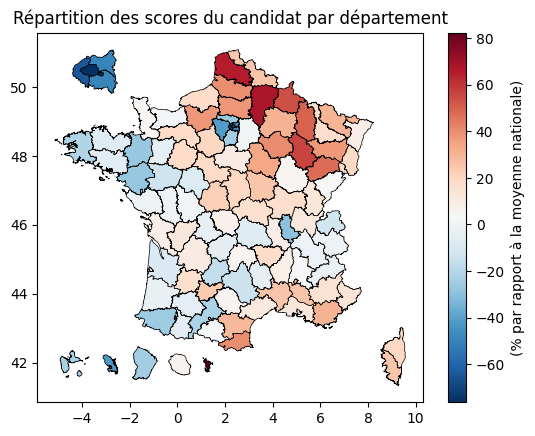

In [ ]:
score_candidat("Marine LE PEN")